In [3]:
import zipfile

zip_path = '/content/Facial Emotion Recognition - 2013 Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction Done!")

Extraction Done!


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = '/content/dataset/train'
test_dir = '/content/dataset/test'

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


#Using the Imagedatagenerator as it will:
  #label the images according to the folder name.
  #Resize the image
  #Flip the image
  #Zoom in zoom out the image
  #Rotate the image

#All these things will help in providing and over fitting or under fitting and model will train well on images


In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)


#Made train and test generator

  #It assigned the label tp classes
    #ex: angry': 0, 'disgusted': 1 etc
  #Defined everything like that size 64 pictures will be taken at once,
  #The class mood categorical as they are multi classes etc.

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [6]:
print(train_generator.class_indices)

#classes after being labelled.

{'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


(np.float64(-0.5), np.float64(47.5), np.float64(47.5), np.float64(-0.5))

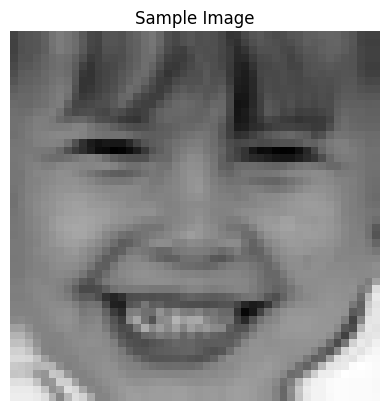

In [7]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.imshow(images[0].reshape(48,48), cmap='gray')
plt.title("Sample Image")
plt.axis('off')

#disply and see sample image.

In [17]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


#set up cnn model and optimizers.

In [18]:
history = model.fit(
    train_generator,
    epochs=20,   # increase epochs
    validation_data=test_generator
)

#trained the model for 20 epochs.

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 174s 379ms/step - accuracy: 0.2718 - loss: 1.8124 - val_accuracy: 0.3041 - val_loss: 1.7179
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 170s 378ms/step - accuracy: 0.3743 - loss: 1.5908 - val_accuracy: 0.4191 - val_loss: 1.4876
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 166s 370ms/step - accuracy: 0.4301 - loss: 1.4762 - val_accuracy: 0.4522 - val_loss: 1.4030
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 167s 371ms/step - accuracy: 0.4666 - loss: 1.3950 - val_accuracy: 0.4298 - val_loss: 1.4325
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 165s 368ms/step - accuracy: 0.4860 - loss: 1.3523 - val_accuracy: 0.5230 - val_loss: 1.2613
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 167s 371ms/step - accuracy: 0.5003 - loss: 1.3175 - val_accuracy: 0.4604 - val_loss: 1.3945
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 165s 368ms/step - accuracy: 0.5156 - loss: 1.2833 - val_accuracy: 0.4599 - val_loss: 1.4234
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 166s 369ms/step - accuracy: 0.5282 -

In [19]:
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)

#check accuracy on test part.

113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.5897 - loss: 1.0796
Test Accuracy: 0.5897185802459717


In [22]:
import os
import cv2
import numpy as np

test_folder = '/content/dataset/test/happy'
emotion_labels = ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']
for file in os.listdir(test_folder)[:5]:
    img_path = os.path.join(test_folder, file)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48,48)) / 255.0
    img = np.reshape(img, (1,48,48,1))

    pred = model.predict(img)
    emotion = emotion_labels[np.argmax(pred)]

    print(file, "->", emotion)


    #test and seen as accurately predicted on happy foloder of the dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
im195.png -> Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
im1490.png -> Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
im1168.png -> Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
im123.png -> Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
im214.png -> Happy
